# Pattern Drop Analytics — Week 2
## Trending Audio Cleaning, Categorization & Brand-Fit Analysis

**Client brief:** Wellness app focused on *motivation and calm energy*. Pick 3 trending TikTok / Reels audio clips that fit a soothing, motivational brand voice.

**Pipeline:**
1. Load the raw dataset
2. Clean: standardize columns, parse numbers, normalize platforms, split categories
3. Deduplicate + validate links
4. Score each clip on brand fit (transparent rubric)
5. Pick top 3 across distinct use-case slots
6. Visualize the dataset and the picks

**Tool choice:** pandas + matplotlib — tabular, reproducible, easy to defend in viva.

##  Imports & paths

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from pathlib import Path

# Paths are relative to this notebook's location (week2/)
RAW = Path('data/trending_audio_clips_dataset.csv')
OUT_DIR = Path('output')
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Audit-trail logger
log_lines = []
def log(msg):
    log_lines.append(msg)
    print(msg)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

BRAND_COLORS = {
    'Calming':      '#6BAED6',
    'Motivational': '#74C476',
    'Uplifting':    '#FDD49E',
    'Upbeat':       '#FDAE6B',
    'Humorous':     '#E6550D',
}

## 1. Load raw dataset

In [3]:
df = pd.read_csv(RAW)
log(f'[LOAD] {len(df)} rows, {len(df.columns)} columns')
log(f'[LOAD] columns = {list(df.columns)}')
df.head()

[LOAD] 75 rows, 7 columns
[LOAD] columns = ['id', 'audio_name', 'artist', 'number_of_uses', 'platform', 'category', 'link']


,id,audio_name,artist,number_of_uses,platform,category,link
0,1,Weightless,Marconi Union,"4,800,000+",TikTok,Calming,https://www.tiktok.com/music/Weightless-690989...
1,2,Nuvole Bianche,Ludovico Einaudi,"5,600,000+",TikTok,Calming,https://www.tiktok.com/music/Nuvole-Bianche-67...
2,3,Clair de Lune (Lo-fi Remix),Debussy / Lo-fi Edit,"3,200,000+",TikTok,Calming,https://www.tiktok.com/music/Clair-de-Lune-Lof...
3,4,Bloom (Bonus Track),The Paper Kites,"1,800,000+",TikTok,Calming,https://www.tiktok.com/music/Bloom-67123456789...
4,5,Holocene,Bon Iver,"4,000,000+",Instagram Reels,Calming,https://www.instagram.com/reels/audio/holocene...


## 2. Clean

Standardize column names → strip whitespace → parse `number_of_uses` to int → normalize `platform` → split compound `category` into primary + secondary.

In [4]:
# 2a. Standardize column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
log(f'[STANDARDIZE] columns: {list(df.columns)}')

# 2b. Strip whitespace, normalize blanks to NA
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()
    df.loc[df[c].isin(['', 'nan', 'None']), c] = pd.NA
log('[STRIP] whitespace stripped on all string columns')

# 2c. Parse number_of_uses (e.g. '4,800,000+') -> integer uses_count
def parse_uses(val):
    if pd.isna(val):
        return None
    s = str(val).replace(',', '').replace('+', '').strip()
    m = re.match(r'^(\d+)$', s)
    return int(m.group(1)) if m else None

df['uses_count'] = df['number_of_uses'].apply(parse_uses)
log(f"[PARSE] number_of_uses -> uses_count. Unparsed: {df['uses_count'].isna().sum()}")
df = df.drop(columns=['number_of_uses'])

# 2d. Normalize platform
df['platform'] = df['platform'].str.title().replace({'Tiktok': 'TikTok'})
log(f"[NORMALIZE] platform values: {sorted(df['platform'].dropna().unique())}")

# 2e. Split compound categories like 'Calming/Meditative'
def split_category(val):
    if pd.isna(val):
        return (None, None)
    parts = [p.strip() for p in str(val).split('/')]
    return (parts[0], parts[1] if len(parts) > 1 else None)

split = df['category'].apply(split_category)
df['category_primary']   = [s[0] for s in split]
df['category_secondary'] = [s[1] for s in split]
df = df.drop(columns=['category'])
log(f"[CATEGORY] primary: {sorted(df['category_primary'].dropna().unique())}")
log(f"[CATEGORY] secondary: {sorted(df['category_secondary'].dropna().unique())}")

df.head()

[STANDARDIZE] columns: ['id', 'audio_name', 'artist', 'number_of_uses', 'platform', 'category', 'link']
[STRIP] whitespace stripped on all string columns
[PARSE] number_of_uses -> uses_count. Unparsed: 0
[NORMALIZE] platform values: ['Instagram Reels', 'TikTok']
[CATEGORY] primary: ['Calming', 'Humorous', 'Motivational', 'Upbeat', 'Uplifting']
[CATEGORY] secondary: ['Hype', 'Meditative', 'Spoken Word', 'Uplifting']


C:\Users\yashs\AppData\Local\Temp\ipykernel_2428\1996363078.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


,id,audio_name,artist,platform,link,uses_count,category_primary,category_secondary
0,1,Weightless,Marconi Union,TikTok,https://www.tiktok.com/music/Weightless-690989...,4800000,Calming,NaN
1,2,Nuvole Bianche,Ludovico Einaudi,TikTok,https://www.tiktok.com/music/Nuvole-Bianche-67...,5600000,Calming,NaN
2,3,Clair de Lune (Lo-fi Remix),Debussy / Lo-fi Edit,TikTok,https://www.tiktok.com/music/Clair-de-Lune-Lof...,3200000,Calming,NaN
3,4,Bloom (Bonus Track),The Paper Kites,TikTok,https://www.tiktok.com/music/Bloom-67123456789...,1800000,Calming,NaN
4,5,Holocene,Bon Iver,Instagram Reels,https://www.instagram.com/reels/audio/holocene...,4000000,Calming,NaN


## 3. Deduplicate + validate links

In [5]:
key_cols = ['audio_name', 'artist', 'uses_count', 'platform']
dupes = df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)
log(f'[DEDUPE] duplicate rows found: {len(dupes)}')
for _, row in dupes.iterrows():
    log(f"  - id={row['id']} | {row['audio_name']} | {row['artist']}")

before = len(df)
df = df.drop_duplicates(subset=key_cols, keep='first').reset_index(drop=True)
log(f'[DEDUPE] removed {before - len(df)} row(s). Now {len(df)} rows.')

url_pattern = re.compile(r'^https?://[^\s]+$')
df['link_valid_format'] = df['link'].apply(
    lambda x: bool(url_pattern.match(str(x))) if pd.notna(x) else False
)
log(f"[VALIDATE] valid URL format: {df['link_valid_format'].sum()}/{len(df)}")
log('[VALIDATE] NOTE: format-valid != resolvable. Manual check needed for final 3.')

df = df.reset_index(drop=True)
df['id'] = df.index + 1

[DEDUPE] duplicate rows found: 2
  - id=44 | Warm Strings (Original) | @mindfulmoments
  - id=69 | Warm Strings (Original) | @mindfulmoments
[DEDUPE] removed 1 row(s). Now 74 rows.
[VALIDATE] valid URL format: 74/74
[VALIDATE] NOTE: format-valid != resolvable. Manual check needed for final 3.


## 4. Brand-fit scoring

**Rubric** (transparent, defensible):

| Component | Logic |
|---|---|
| Primary category fit | Calming=4, Motivational=4, Uplifting=3, Upbeat=1, Humorous=0 |
| Secondary modifier | +1 if Meditative / Spoken Word / Uplifting; −2 if Hype |
| Popularity bonus | log-scaled `uses_count`, 0–3 points |
| Original-sound bonus | +1 if artist starts with `@` |

In [6]:
PRIMARY_FIT = {'Calming': 4, 'Motivational': 4, 'Uplifting': 3, 'Upbeat': 1, 'Humorous': 0}
SECONDARY_MOD = {'Meditative': 1, 'Spoken Word': 1, 'Uplifting': 1, 'Hype': -2}

max_uses = df['uses_count'].max()

def is_original_sound(artist):
    return pd.notna(artist) and str(artist).startswith('@')

def brand_fit_score(row):
    score = PRIMARY_FIT.get(row['category_primary'], 0)
    score += SECONDARY_MOD.get(row['category_secondary'], 0)
    if pd.notna(row['uses_count']) and row['uses_count'] > 0:
        score += math.log10(row['uses_count']) / math.log10(max_uses) * 3
    if is_original_sound(row['artist']):
        score += 1
    return round(score, 2)

df['is_original_sound'] = df['artist'].apply(is_original_sound)
df['brand_fit_score']   = df.apply(brand_fit_score, axis=1)
log(f"[SCORE] brand_fit range: {df['brand_fit_score'].min():.2f} -> {df['brand_fit_score'].max():.2f}")

df = df[['id','audio_name','artist','is_original_sound','platform','category_primary','category_secondary','uses_count','brand_fit_score','link','link_valid_format']]

clean_path = OUT_DIR / 'trending_audio_cleaned.csv'
df.to_csv(clean_path, index=False)
log(f'[WRITE] cleaned dataset -> {clean_path}')
df.head()

[SCORE] brand_fit range: 1.81 -> 8.71
[WRITE] cleaned dataset -> output\trending_audio_cleaned.csv


,id,audio_name,artist,is_original_sound,platform,category_primary,category_secondary,uses_count,brand_fit_score,link,link_valid_format
0,1,Weightless,Marconi Union,False,TikTok,Calming,NaN,4800000,6.73,https://www.tiktok.com/music/Weightless-690989...,True
1,2,Nuvole Bianche,Ludovico Einaudi,False,TikTok,Calming,NaN,5600000,6.76,https://www.tiktok.com/music/Nuvole-Bianche-67...,True
2,3,Clair de Lune (Lo-fi Remix),Debussy / Lo-fi Edit,False,TikTok,Calming,NaN,3200000,6.66,https://www.tiktok.com/music/Clair-de-Lune-Lof...,True
3,4,Bloom (Bonus Track),The Paper Kites,False,TikTok,Calming,NaN,1800000,6.56,https://www.tiktok.com/music/Bloom-67123456789...,True
4,5,Holocene,Bon Iver,False,Instagram Reels,Calming,NaN,4000000,6.70,https://www.instagram.com/reels/audio/holocene...,True


## 5. Top 3 selection

Picking for **use-case diversity**, not just raw score:
- **Slot A — Calming instrumental** (ambient B-roll, meditation intros)
- **Slot B — Motivational track** (morning routine, workout reels)
- **Slot C — Spoken-word affirmation** (caption-led mindset posts)

Within each slot: prefer **named artists** over generic `@handle` originals when scores are close.

In [7]:
def pick_slot(filtered_df):
    if not len(filtered_df):
        return None
    sorted_df = filtered_df.sort_values(['is_original_sound','brand_fit_score'], ascending=[True, False])
    return sorted_df.iloc[0]

slot_a = pick_slot(df[df['category_primary']   == 'Calming'])
slot_b = pick_slot(df[df['category_primary']   == 'Motivational'])
slot_c = pick_slot(df[df['category_secondary'] == 'Spoken Word'])

picks = [p for p in [slot_a, slot_b, slot_c] if p is not None]
remaining = df[~df['id'].isin([p['id'] for p in picks])].sort_values('brand_fit_score', ascending=False)
while len(picks) < 3 and len(remaining):
    picks.append(remaining.iloc[0])
    remaining = remaining.iloc[1:]

top3 = pd.DataFrame(picks).reset_index(drop=True)
top3.insert(0, 'slot', ['A - Calming', 'B - Motivational', 'C - Spoken Word'][:len(top3)])

top3_path = OUT_DIR / 'top3_selections.csv'
top3.to_csv(top3_path, index=False)
log(f'[SELECT] top 3 -> {top3_path}')
for _, r in top3.iterrows():
    log(f"  {r['slot']}: {r['audio_name']} by {r['artist']} | score={r['brand_fit_score']} | uses={r['uses_count']:,}")
top3[['slot','audio_name','artist','platform','category_primary','category_secondary','uses_count','brand_fit_score','link']]

[SELECT] top 3 -> output\top3_selections.csv
  A - Calming: Golden Hour by JVKE | score=7.9 | uses=12,500,000
  B - Motivational: Rise Up by Andra Day | score=6.78 | uses=6,200,000
  C - Spoken Word: You Are Enough (Affirmation) by @mindsetcoachpro | score=8.71 | uses=4,200,000


,slot,audio_name,artist,platform,category_primary,category_secondary,uses_count,brand_fit_score,link
0,A - Calming,Golden Hour,JVKE,TikTok,Calming,Uplifting,12500000,7.90,https://www.tiktok.com/music/golden-hour-69784...
1,B - Motivational,Rise Up,Andra Day,TikTok,Motivational,NaN,6200000,6.78,https://www.tiktok.com/music/Rise-Up-702345678...
2,C - Spoken Word,You Are Enough (Affirmation),@mindsetcoachpro,TikTok,Motivational,Spoken Word,4200000,8.71,https://www.tiktok.com/music/You-Are-Enough-71...


## 6. Visualizations

All plots are saved to `output/plots/` so they can be dropped straight into the slide deck.

### 6.1 Platform distribution

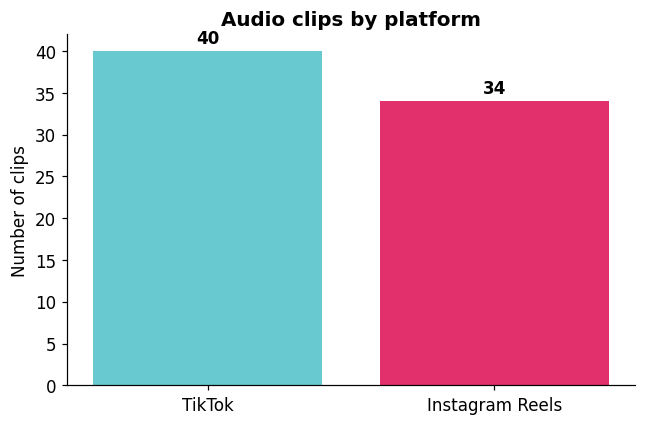

In [8]:
platform_counts = df['platform'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(platform_counts.index, platform_counts.values, color=['#69C9D0','#E1306C'][:len(platform_counts)])
ax.set_title('Audio clips by platform', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of clips')
for bar, val in zip(bars, platform_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '01_platform_distribution.png')
plt.show()

### 6.2 Category distribution

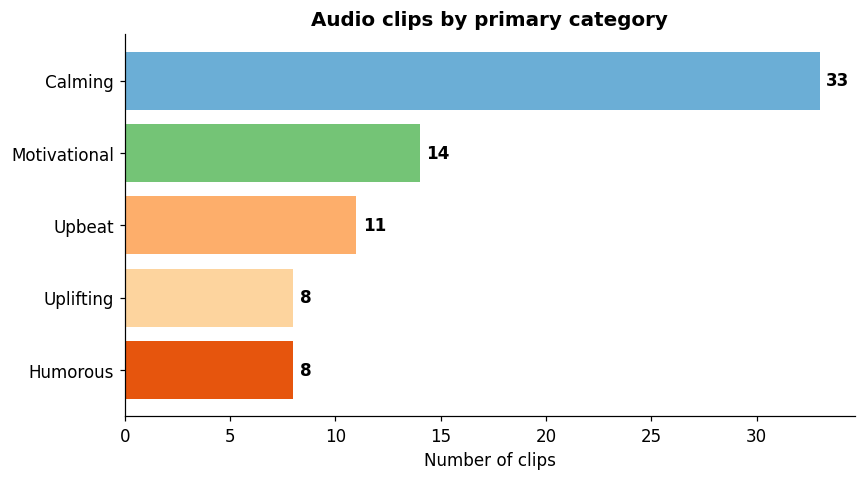

In [9]:
cat_counts = df['category_primary'].value_counts()
colors = [BRAND_COLORS.get(c, '#999999') for c in cat_counts.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1])
ax.set_title('Audio clips by primary category', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of clips')
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_category_distribution.png')
plt.show()

### 6.3 Top 10 most-used clips

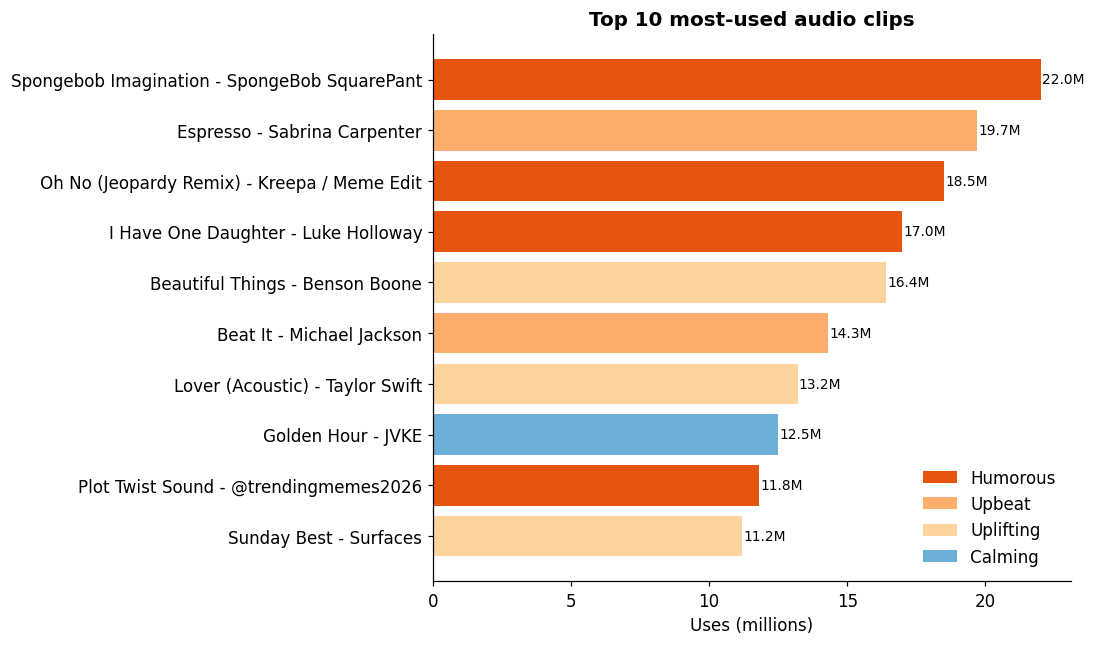

In [10]:
from matplotlib.patches import Patch
top10 = df.nlargest(10, 'uses_count').copy()
top10['label'] = top10['audio_name'].str.slice(0, 35) + ' - ' + top10['artist'].fillna('').str.slice(0, 20)
colors = [BRAND_COLORS.get(c, '#999999') for c in top10['category_primary']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['label'][::-1], top10['uses_count'][::-1] / 1_000_000, color=colors[::-1])
ax.set_title('Top 10 most-used audio clips', fontsize=13, fontweight='bold')
ax.set_xlabel('Uses (millions)')
for bar, val in zip(bars, top10['uses_count'][::-1] / 1_000_000):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}M', va='center', fontsize=9)

legend_items = [Patch(facecolor=BRAND_COLORS[c], label=c) for c in top10['category_primary'].unique() if c in BRAND_COLORS]
ax.legend(handles=legend_items, loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_top10_uses.png')
plt.show()

### 6.4 Brand-fit score - distribution and by category

C:\Users\yashs\AppData\Local\Temp\ipykernel_2428\3771686470.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_cat, labels=order, patch_artist=True, widths=0.6)


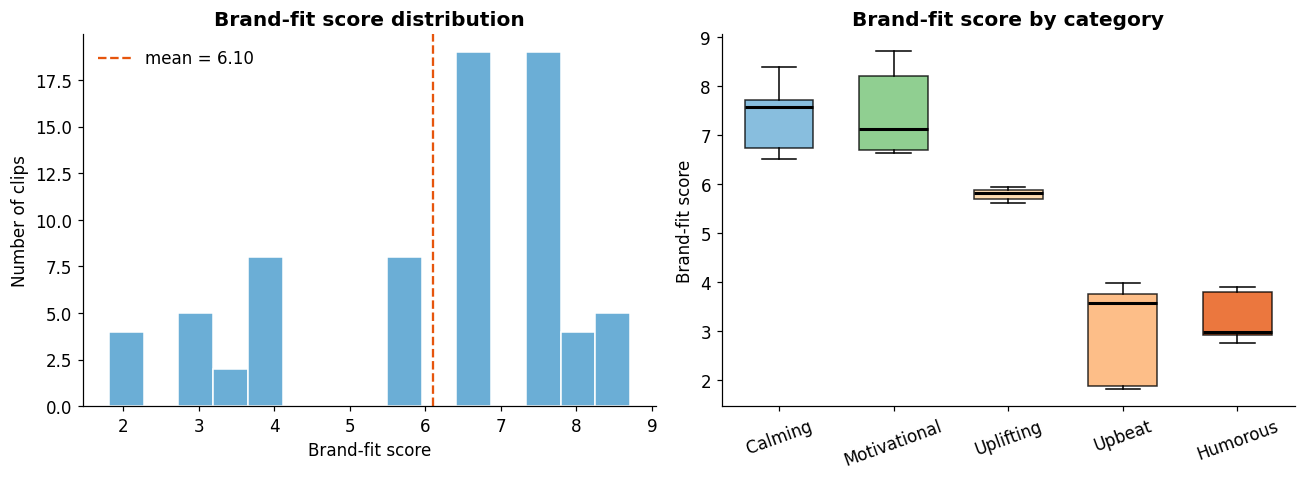

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['brand_fit_score'], bins=15, color='#6BAED6', edgecolor='white')
axes[0].axvline(df['brand_fit_score'].mean(), color='#E6550D', linestyle='--', label=f"mean = {df['brand_fit_score'].mean():.2f}")
axes[0].set_title('Brand-fit score distribution', fontweight='bold')
axes[0].set_xlabel('Brand-fit score')
axes[0].set_ylabel('Number of clips')
axes[0].legend(frameon=False)

order = [c for c in ['Calming','Motivational','Uplifting','Upbeat','Humorous'] if c in df['category_primary'].unique()]
data_by_cat = [df.loc[df['category_primary'] == c, 'brand_fit_score'].values for c in order]
bp = axes[1].boxplot(data_by_cat, labels=order, patch_artist=True, widths=0.6)
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(BRAND_COLORS.get(c, '#999999'))
    patch.set_alpha(0.8)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
axes[1].set_title('Brand-fit score by category', fontweight='bold')
axes[1].set_ylabel('Brand-fit score')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(PLOT_DIR / '04_score_distribution.png')
plt.show()

### 6.5 Uses vs brand-fit - with top 3 highlighted

The sweet spot is **high uses + high brand fit** (top-right). The picks should sit in that quadrant.

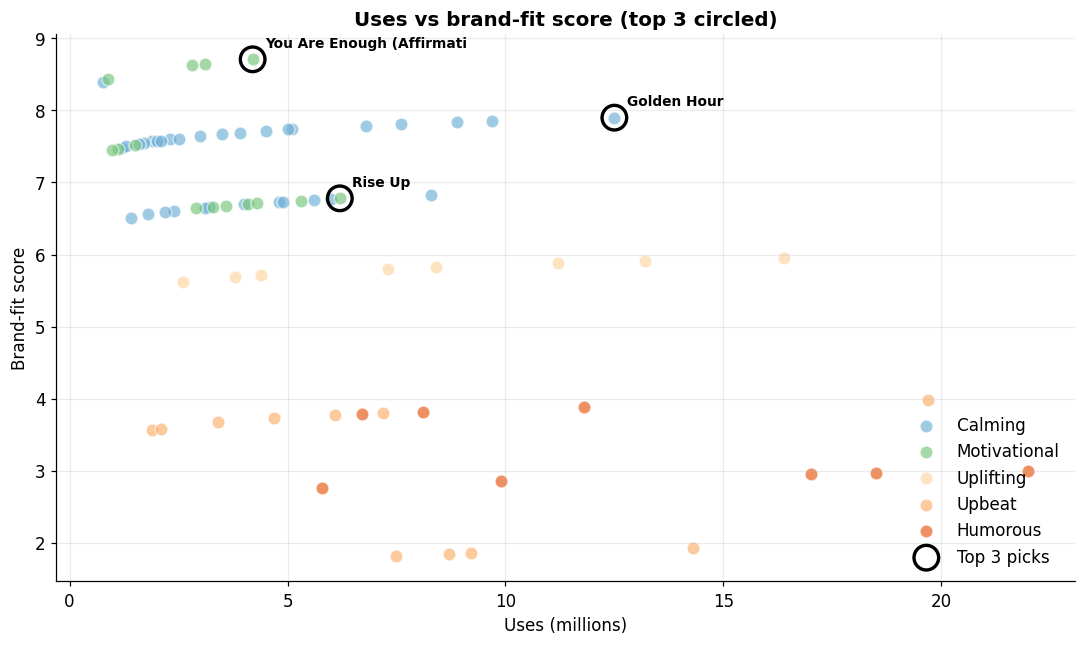

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for cat in df['category_primary'].dropna().unique():
    sub = df[df['category_primary'] == cat]
    ax.scatter(sub['uses_count'] / 1_000_000, sub['brand_fit_score'], s=70, alpha=0.65, color=BRAND_COLORS.get(cat, '#999999'), edgecolor='white', linewidth=0.8, label=cat)

ax.scatter(top3['uses_count'] / 1_000_000, top3['brand_fit_score'], s=260, facecolor='none', edgecolor='#000000', linewidth=2.2, label='Top 3 picks', zorder=5)

for _, r in top3.iterrows():
    ax.annotate(r['audio_name'][:25], (r['uses_count'] / 1_000_000, r['brand_fit_score']), xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_title('Uses vs brand-fit score (top 3 circled)', fontsize=13, fontweight='bold')
ax.set_xlabel('Uses (millions)')
ax.set_ylabel('Brand-fit score')
ax.legend(frameon=False, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / '05_uses_vs_score_scatter.png')
plt.show()

### 6.6 The top 3 picks

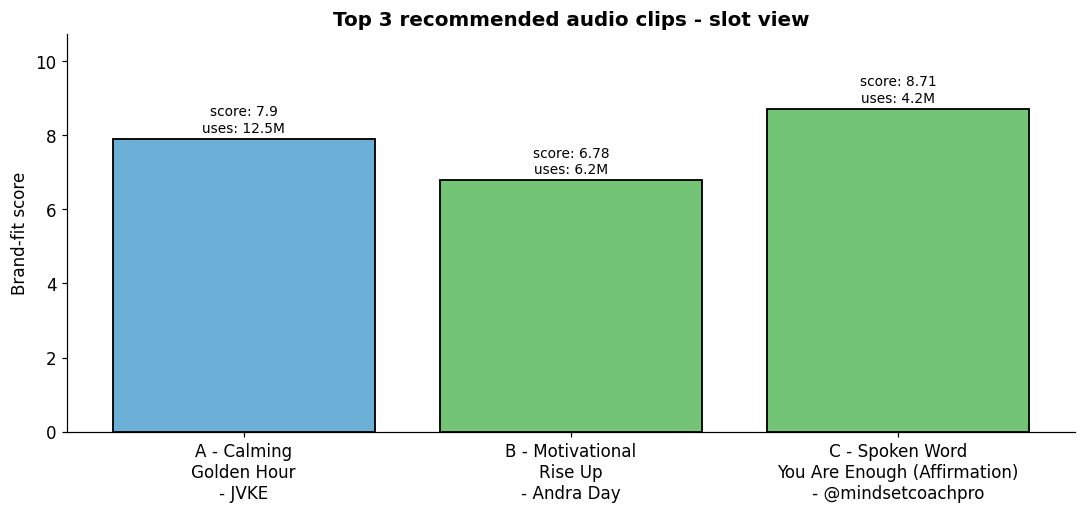

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8))

labels = [f"{r['slot']}\n{r['audio_name'][:30]}\n- {str(r['artist'])[:25]}" for _, r in top3.iterrows()]
colors = [BRAND_COLORS.get(c, '#999999') for c in top3['category_primary']]

bars = ax.bar(labels, top3['brand_fit_score'], color=colors, edgecolor='black', linewidth=1.2)
for bar, score, uses in zip(bars, top3['brand_fit_score'], top3['uses_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'score: {score}\nuses: {uses/1_000_000:.1f}M', ha='center', va='bottom', fontsize=9)

ax.set_title('Top 3 recommended audio clips - slot view', fontsize=13, fontweight='bold')
ax.set_ylabel('Brand-fit score')
ax.set_ylim(0, top3['brand_fit_score'].max() + 2)
plt.tight_layout()
plt.savefig(PLOT_DIR / '06_top3_picks.png')
plt.show()

## 7. Write audit log + final summary

In [14]:
log_path = OUT_DIR / 'cleaning_log.txt'
log_path.write_text('\n'.join(log_lines))
print(f'\nLog written to {log_path}')

print('\n=== FINAL SHAPE ===')
print(df.shape)

print('\n=== CATEGORY PRIMARY COUNTS ===')
print(df['category_primary'].value_counts())

print('\n=== TOP 3 ===')
print(top3[['slot','audio_name','artist','category_primary','category_secondary','platform','uses_count','brand_fit_score','link']].to_string(index=False))


Log written to output\cleaning_log.txt

=== FINAL SHAPE ===
(74, 11)

=== CATEGORY PRIMARY COUNTS ===
category_primary
Calming         33
Motivational    14
Upbeat          11
Uplifting        8
Humorous         8
Name: count, dtype: int64

=== TOP 3 ===
            slot                   audio_name           artist category_primary category_secondary platform  uses_count  brand_fit_score                                                            link
     A - Calming                  Golden Hour             JVKE          Calming          Uplifting   TikTok    12500000             7.90    https://www.tiktok.com/music/golden-hour-6978492182063931393
B - Motivational                      Rise Up        Andra Day     Motivational                NaN   TikTok     6200000             6.78        https://www.tiktok.com/music/Rise-Up-7023456789012345678
 C - Spoken Word You Are Enough (Affirmation) @mindsetcoachpro     Motivational        Spoken Word   TikTok     4200000             8.71 http